<a href="https://www.kaggle.com/code/phillipgregory1994/fraud-detection-understanding-f1-score-1?scriptVersionId=256296356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Payment Fraud Classification

## Introduction

The main goal of this notebook is to demonstrate a variety of classification models in the context of fraud detection and discuss their respective classification metrics. Technical concepts considered include:

* Exploratory Data Analysis (EDA)
* Class imbalance
* Cross validation
* Hyperparameter tuning
* Pipeline development
* Model interpretation
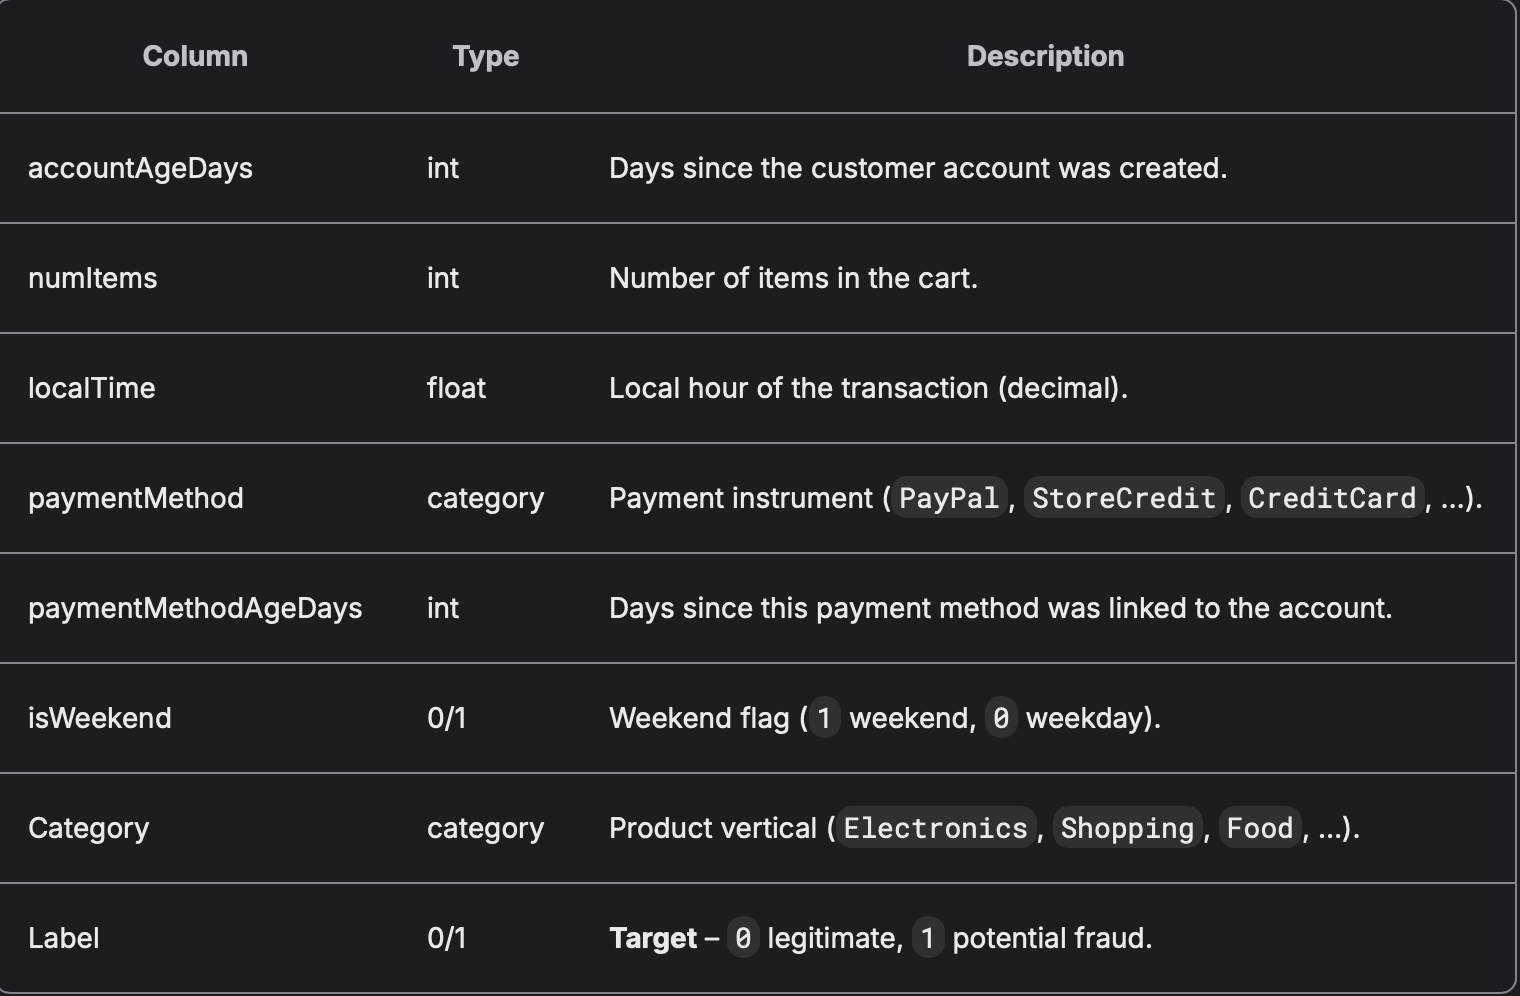

In [1]:
# Ensuring compatibility between scikit-learn and imblearn
!uv pip install -q scikit-learn==1.6.1 imblearn --system

In [2]:
# Basic Imports
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from imblearn.over_sampling import SMOTE

# Pipelines & transformations
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Statistics
from scipy.stats import chi2_contingency

# Warnings
import warnings
warnings.filterwarnings("ignore", message="invalid value encountered in greater", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in less", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning)

## EDA 

In [3]:
# Load in dataset and preview
df = pd.read_csv('/kaggle/input/payment-fraud-empowering-financial-security/payment_fraud.csv')
df.head()

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,Category,isWeekend,label
0,29,1,4.745402,paypal,28.204861,shopping,0.0,0
1,725,1,4.742303,storecredit,0.000000,electronics,0.0,0
2,845,1,4.921318,creditcard,0.000000,food,1.0,0
3,503,1,4.886641,creditcard,0.000000,electronics,1.0,0
4,2000,1,5.040929,creditcard,0.000000,shopping,0.0,0


In [4]:
# Generate basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39221 entries, 0 to 39220
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accountAgeDays        39221 non-null  int64  
 1   numItems              39221 non-null  int64  
 2   localTime             39221 non-null  float64
 3   paymentMethod         39221 non-null  object 
 4   paymentMethodAgeDays  39221 non-null  float64
 5   Category              39126 non-null  object 
 6   isWeekend             38661 non-null  float64
 7   label                 39221 non-null  int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 2.4+ MB


In [5]:
# Check distribution of target
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
0    38661
1      560
Name: count, dtype: int64
label
0    0.985722
1    0.014278
Name: proportion, dtype: float64


The dataset is highly imbalanced, with only 560 (1.4%) transactions classed as fraudulent. This will be a consideration during modelling.

In [6]:
# Investigate nulls in the dataframe
mask = (df['Category'].isnull()) | (df['isWeekend'].isnull()) 

df[mask]

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,Category,isWeekend,label
109,1,4,4.836982,creditcard,0.000000,electronics,NaN,1
243,1,1,4.836982,paypal,0.002778,electronics,NaN,1
280,1,1,4.921318,creditcard,0.000000,shopping,NaN,1
362,1,1,4.524580,paypal,0.000000,food,NaN,1
420,1,1,4.748314,paypal,0.000000,food,NaN,1
...,...,...,...,...,...,...,...,...
38830,1,2,4.876771,creditcard,0.000000,NaN,NaN,1
38880,1,1,4.876771,creditcard,0.000000,NaN,NaN,1
39005,1,1,4.505662,creditcard,0.000000,NaN,NaN,1
39111,1,3,4.748314,creditcard,0.025000,NaN,NaN,1


In [7]:
# Check how many fraud transactions are related to records containing nulls
print(f"{df[mask]['label'].sum()} out of {df['label'].sum()}")

560 out of 560


All 560 of the fraudulent transacions contained null values, indicating the absence of certain information such as category or transaction date could be a strong predictor of fraud

In [8]:
# Impute 'unknown' for missing values
df_full = df.fillna('unknown')

# Check if any nulls remain
df_full.isna().any().any()

False

In [9]:
# Generate statistical overview table
df_full.describe()

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label
count,39221.000000,39221.000000,39221.000000,39221.000000,39221.000000
mean,857.563984,1.084751,4.748232,122.641326,0.014278
std,804.788212,0.566899,0.389360,283.569177,0.118636
min,1.000000,1.000000,0.421214,0.000000,0.000000
25%,72.000000,1.000000,4.742303,0.000000,0.000000
50%,603.000000,1.000000,4.886641,0.012500,0.000000
75%,1804.000000,1.000000,4.962055,87.510417,0.000000
max,2000.000000,29.000000,5.040929,1999.580556,1.000000


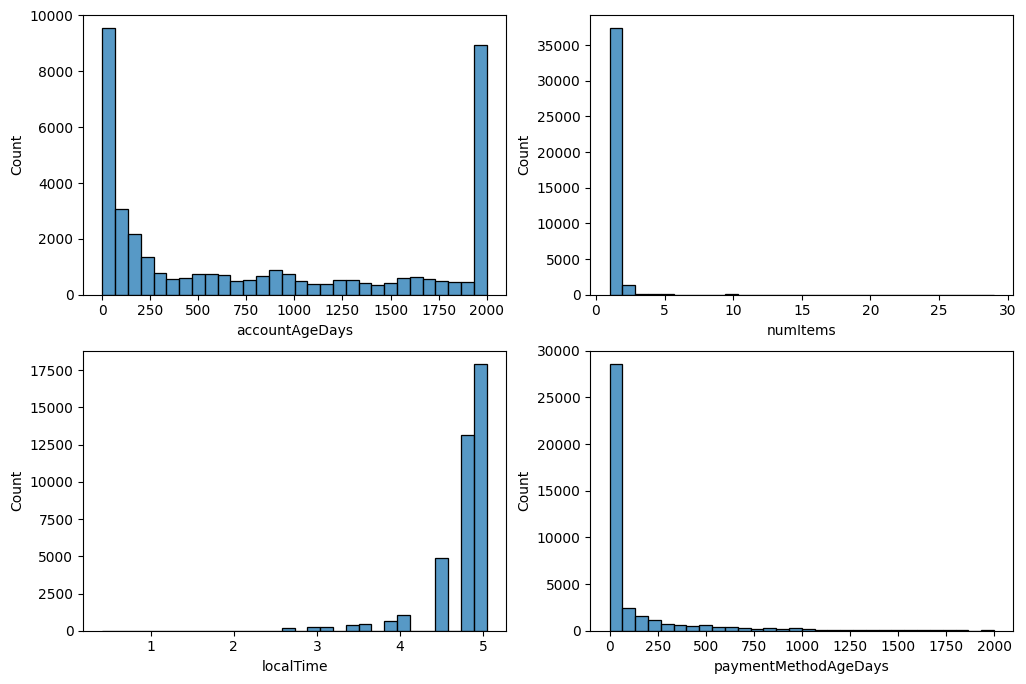

In [10]:
# Visualise numeric independent variable distributions
num_cols = df_full.drop(columns='label').select_dtypes(include='number').columns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_full[col], bins=30, ax=axes[i])

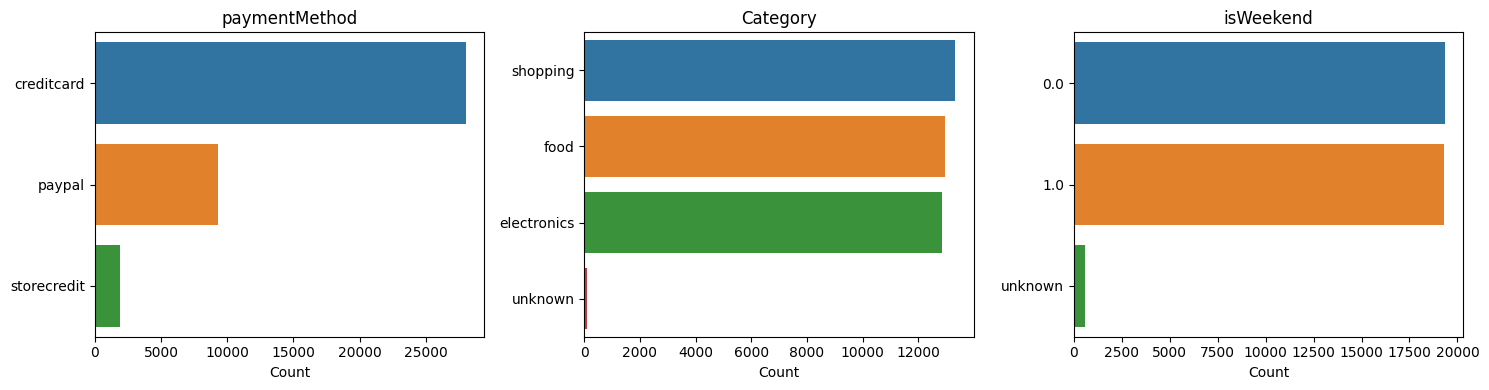

In [11]:
# Select object and category columns
cat_cols = df_full.select_dtypes(include=['object', 'category']).columns

plt.figure(figsize=(15,4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(y=col, data=df_full, order=df_full[col].value_counts().index)
    plt.title(col)
    plt.xlabel("Count")
    plt.ylabel("")

plt.tight_layout()
plt.show()

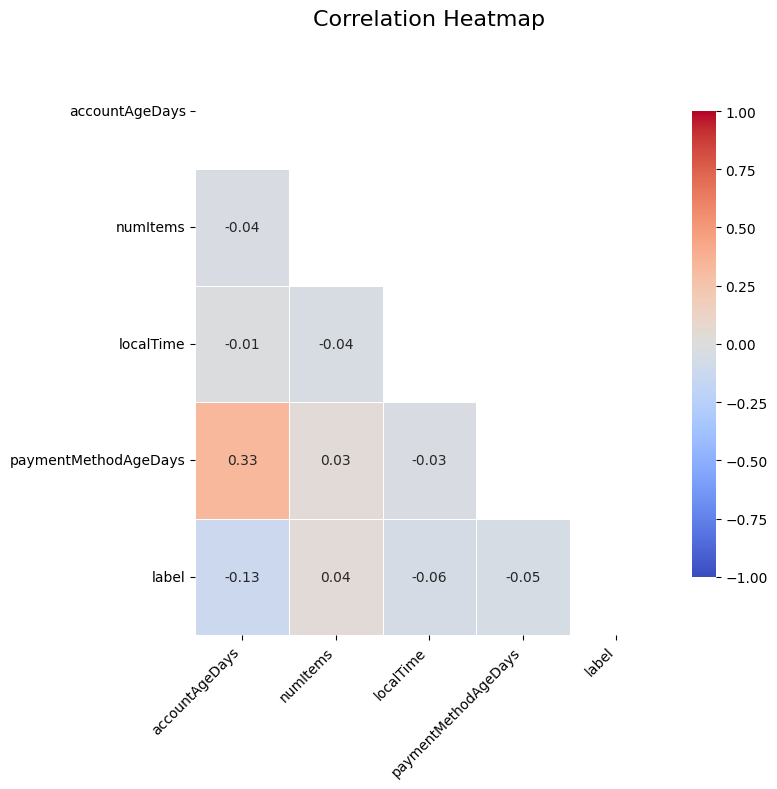

In [12]:
# Check correlation between numerical independent variable and label
corr_cols = num_cols.to_list() + ['label']
corr = df_full[corr_cols].corr()

# Hide the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,         
    fmt=".2f",         
    vmin=-1, vmax=1,   
    linewidths=0.5,     
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Heatmap", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

* Slight negative correlation between accountAgeDays and paymentMethodAgeDays
* Positive correlation between accountAgeDays and paymentMethodAgeDays. May need to drop one of these to avoid collinaerity.

In [13]:
# Check association between categorical festures and the label
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y) # Create cross-tab
    chi2 = chi2_contingency(confusion_matrix)[0] # Get the chi-squared value
    n = confusion_matrix.sum().sum() 
    phi2 = chi2 / n # Normalise
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = df_full.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"{col}: {cramers_v(df_full[col], df_full['label']):.3f}")

paymentMethod: 0.000
Category: 0.028
isWeekend: 1.000


In [14]:
# Explore isWeekend further
df_full[['isWeekend', 'label']].groupby('isWeekend').sum()

,label
isWeekend,
0.0,0
1.0,0
unknown,560


* The perfect association of 'isWeekend' to potentially fraudulent transactions will cause models to overfit the training data, so this needs to be dropped so the model can generalise to unseen data
* Specifically, if isWeekend is unknown, the transaction is marked as potentially fraudulent 100% of the time

In [15]:
# Drop isWeekend
df_full = df_full.drop(columns='isWeekend')

## Modelling

* In this section, I will begin with a Logistic Regression, followed by Decision Tree, followed by RandomForestClassifier
* The first two models are simple and interpretable, whilst the RandomForestClassifier is an ensemble method which is less interpretable

In [16]:
# Review numerical feature distribution
df_full.describe()

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label
count,39221.000000,39221.000000,39221.000000,39221.000000,39221.000000
mean,857.563984,1.084751,4.748232,122.641326,0.014278
std,804.788212,0.566899,0.389360,283.569177,0.118636
min,1.000000,1.000000,0.421214,0.000000,0.000000
25%,72.000000,1.000000,4.742303,0.000000,0.000000
50%,603.000000,1.000000,4.886641,0.012500,0.000000
75%,1804.000000,1.000000,4.962055,87.510417,0.000000
max,2000.000000,29.000000,5.040929,1999.580556,1.000000


In [17]:
# Make pipeline
scale_features = [col for col in num_cols if col != 'localTime']
non_scale_features = ['localTime']  # Small range so no scaling required
cat_features = [col for col in cat_cols if col != 'isWeekend'] # isWeekend is to be excluded from the model as mentioned above


# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('standardiser', StandardScaler(), scale_features), # Apply standard scaler to scale_feature list
        ('pass', 'passthrough', non_scale_features), # Don't transform localTime
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features) # One hot Encode categorical columns
    ]
)

# Construct Pipeline with LogisticRegression as base model
pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),  # Create more synthetic samples of minority class (possible fraud)
        ('clf', LogisticRegression(max_iter=5000)) # Hyperparameters will be tuned during cross-validation
    ]
)

In [18]:
# Isolate predictors and the target
df_model = df_full.copy()
X = df_model.drop(columns='label')
y = df_model['label']

# Split the data into train and test data ensuring stratification of the target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [19]:
# Define param grids for cross validation
param_grid_lr = {
    'clf': [LogisticRegression(max_iter=500)],
    'clf__penalty': ['l2'],            
    'clf__C': [0.1, 1, 10],            
    'clf__solver': ['liblinear'],       
    'clf__class_weight': ['balanced']
}

param_grid_dt = {
    'clf': [DecisionTreeClassifier()],
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [5, 10, 20],        
    'clf__min_samples_split': [5, 10],     
    'clf__min_samples_leaf': [5, 10],      
    'clf__class_weight': ['balanced']       
}

# Random Forest - reduced overfitting
param_grid_rf = {
    'clf': [RandomForestClassifier()],
    'clf__n_estimators': [100, 200],      
    'clf__max_depth': [10, 20, None],      
    'clf__min_samples_split': [5, 10],     
    'clf__min_samples_leaf': [5, 10],      
    'clf__class_weight': ['balanced_subsample'] 
}

In [20]:
# Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch for cross-vaidation across model types and hyperparameter permutations
grid = GridSearchCV(
    estimator = pipe,
    param_grid = [param_grid_lr, param_grid_dt, param_grid_rf],
    scoring = 'f1', # Using f1 score instead of the usual accuracy metric due to imbalanced dataset
    cv = cv,
    n_jobs=-1
)

In [21]:
# Fit models
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('standardiser',
                                                                         StandardScaler(),
                                                                         ['accountAgeDays',
                                                                          'numItems',
                                                                          'paymentMethodAgeDays']),
                                                                        ('pass',
                                                                         'passthrough',
                                                                         ['localTime']),
                                                                        ('ohe',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['paymentMethod',
                                                                          'Ca...
                          'clf__class_weight': ['balanced'],
                          'clf__criterion': ['gini', 'entropy'],
                          'clf__max_depth': [5, 10, 20],
                          'clf__min_samples_leaf': [5, 10],
                          'clf__min_samples_split': [5, 10]},
                         {'clf': [RandomForestClassifier()],
                          'clf__class_weight': ['balanced_subsample'],
                          'clf__max_depth': [10, 20, None],
                          'clf__min_samples_leaf': [5, 10],
                          'clf__min_samples_split': [5, 10],
                          'clf__n_estimators': [100, 200]}],
             scoring='f1')

In [22]:
# Get model results in a dataframe
results = pd.DataFrame(grid.cv_results_)
results

# Best results per classifier
best_params_per_clf = {}
for clf in results['param_clf'].unique():
    subset = results[results['param_clf'] == clf]
    best_idx = subset['mean_test_score'].idxmax()
    best_params_per_clf[clf] = results.loc[best_idx, 'params']

print("Best params per classifier:")
print(best_params_per_clf)

Best params per classifier:
{LogisticRegression(max_iter=500): {'clf': LogisticRegression(max_iter=500), 'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}, DecisionTreeClassifier(): {'clf': DecisionTreeClassifier(), 'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 5}, RandomForestClassifier(): {'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}}


In [23]:
# Get classification reports for each classifier with optimal hyperparameters
for clf, params in best_params_per_clf.items():
    print(f"\n=== {clf} ===")
    
    # Configure pipeline with best params
    best_model = grid.estimator.set_params(**params)
    
    # Get cross-validated predictions
    y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
    
    # Report metrics
    print(classification_report(y, y_pred))


=== LogisticRegression(max_iter=500) ===
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     38661
           1       0.12      1.00      0.21       560

    accuracy                           0.89     39221
   macro avg       0.56      0.95      0.58     39221
weighted avg       0.99      0.89      0.93     39221


=== DecisionTreeClassifier() ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38661
           1       1.00      1.00      1.00       560

    accuracy                           1.00     39221
   macro avg       1.00      1.00      1.00     39221
weighted avg       1.00      1.00      1.00     39221


=== RandomForestClassifier() ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38661
           1       1.00      1.00      1.00       560

    accuracy                           1.00     39221
   macro avg      

* The logistic regresion model performed poorly in correctly predicting positive fraud cases due to the low precision of 0.12. This means that only 12% of predicted fraudulent transactions were actually fraudulent, which is insufficient.
* Both the decision tree and random forest achieved a F1-Score of 1 when predicting across validation folds
* I will opt for the simpler decision tree as it is easier to interpret than a random forest

In [24]:
# Isolate the best model and predict on the unseen test data. Recheck the classification report
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Get the classifier name
clf_name = best_model.named_steps['clf'].__class__.__name__

print(f"Classification Report for {clf_name}:\n")
print(classification_report(y_test, y_pred))

Classification Report for DecisionTreeClassifier:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7733
           1       1.00      1.00      1.00       112

    accuracy                           1.00      7845
   macro avg       1.00      1.00      1.00      7845
weighted avg       1.00      1.00      1.00      7845



* The decision tree classifier performs perfectly on the unseen data, as it did on the cross validation folds.

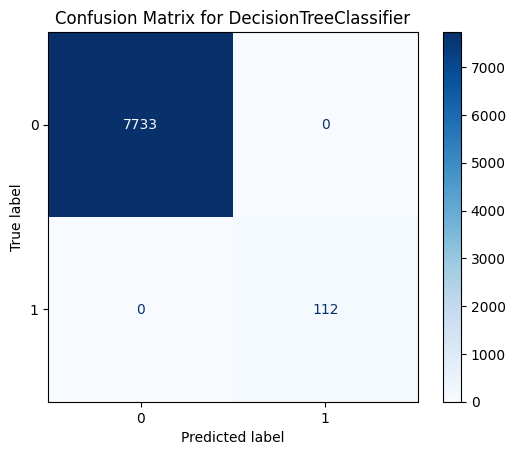

In [25]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d') 
plt.title(f'Confusion Matrix for {best_model.named_steps["clf"].__class__.__name__}')
plt.show()

* All true positives and true negatives were correctly predicted

## Interpretation

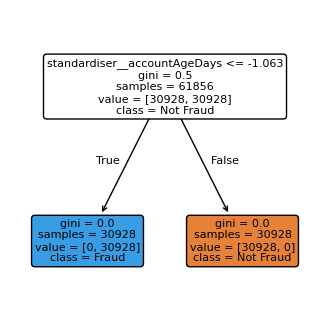

In [26]:
# Plot decision tree
best_tree = best_model.named_steps['clf']  # from your pipeline

plt.figure(figsize=(4,4))
tree.plot_tree(
    best_tree,
    feature_names=best_model.named_steps['preprocessor'].get_feature_names_out(),
    class_names=['Not Fraud','Fraud'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

* There is only 1 split required to perfectly identify potentially fraudulent transactions

In [27]:
# Get the fitted StandardScaler from the pipeline
scaler = best_model.named_steps['preprocessor'].named_transformers_['standardiser']
numeric_features = scaler.feature_names_in_
idx = list(numeric_features).index('accountAgeDays')
mean = scaler.mean_[idx]
std = scaler.scale_[idx]

# Convert scaled threshold back to original units
threshold_scaled = -1.063  # from decision tree plot
threshold_original = threshold_scaled * std + mean

print(f"Threshold in original units: {threshold_original:.2f} days")

Threshold in original units: 1.31 days


In [28]:
# Confirm observation that any fraudlent transactions relate to thode with an account age of less than 1.31 days
fraud_by_days = df_full[df_full['accountAgeDays'] <= 1]['label'].sum()
all_fraud = df_full[df_full['label'] == 1]['label'].sum()

print(f"{100 * fraud_by_days/all_fraud}% of potentially fraudulent transactions have account age of less than 1.31 days.")

100.0% of potentially fraudulent transactions have account age of less than 1.31 days.


## Summary

* The optimal model for prediction for this dataset was the DecisionTree
* The ability to visualise a decision tree to interpret how the classifier worked was pivotal in opting for decision tree over random forest
* As the model simply labels all transactions as potentially fraudulent when the account age is less than 1.31 days, my business reccomendation would be to *not use this model* in a real-life situation
* The model is oversimplified and could lead to customer dissatisfaction if they are being unfairly investigated or questioned about legitimate transactions. This could then result in damaged business reputation and high churn rate amongst new customers.
* The business should gather more data and more features so the model can learn a more generalised approach to classifying fraudulent trsnactions.